In [2]:
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as utils
import sys,os
import torch
sys.path.append("/home/sambt/CASE_final/CASE_QUAK_final/finalTraining")
import trainingTools as tools
import jammy_flows as jf
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
torch.set_default_tensor_type('torch.cuda.FloatTensor') if torch.cuda.is_available() else print ('cpu')

/nobackup/users/sambt/anaconda3/envs/quak/lib/python3.7/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
variables = ['jet1_rho','jet1_logTauS','jet1_tau21','jet1_npf','jet1_tau32','jet1_tau43','jet1_pb']
#variables=variables[:1]
train = tools.loadData("QCDBKG_mjjFlat",2017,variables,100000)
#train[train==0]+=np.random.rand(np.count_nonzero(train==0))
#train = np.log(1.0/(1.0-train))
mean,std = tools.loadMeans("QCDBKG",2017,variables)
train = (train-mean)/std
train = train.astype('float64')

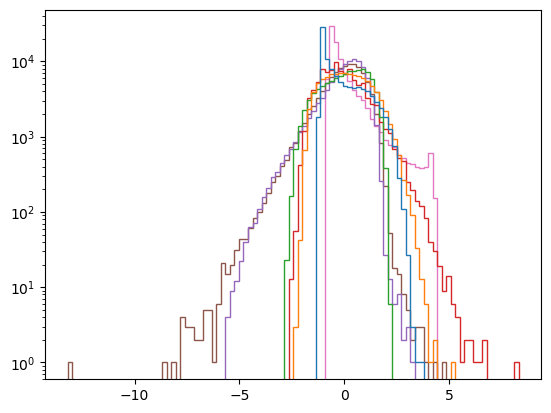

In [6]:
h = plt.hist(train,histtype='step',bins=100)
plt.yscale('log')

In [7]:
lo,hi = np.min(train,axis=0)-0.1, np.max(train,axis=0)+0.1
arch_string = "+".join([f"i1_{lo[i]:.1f}_{hi[i]:.1f}" for i in range(len(variables))])
flow_string = "+".join(["rrrrr" for _ in variables])
opts = dict()
opts["r"] = {"num_basis_elements":300}
mlp_dims = ["250-250-250"]*(len(variables))
flow = jf.pdf(arch_string,flow_string,options_overwrite=opts,amortization_mlp_dims=mlp_dims).to(device)

options overwrite  num_basis_elements
options overwrite  num_basis_elements
options overwrite  num_basis_elements
options overwrite  num_basis_elements
options overwrite  num_basis_elements
options overwrite  num_basis_elements
options overwrite  num_basis_elements


Iteration 10 Complete
Loss:  8.337213700687627
Iteration 20 Complete
Loss:  7.359708982145283
Iteration 30 Complete
Loss:  6.905747639462145
Iteration 40 Complete
Loss:  6.936991451691365
Iteration 50 Complete
Loss:  6.770036857207453


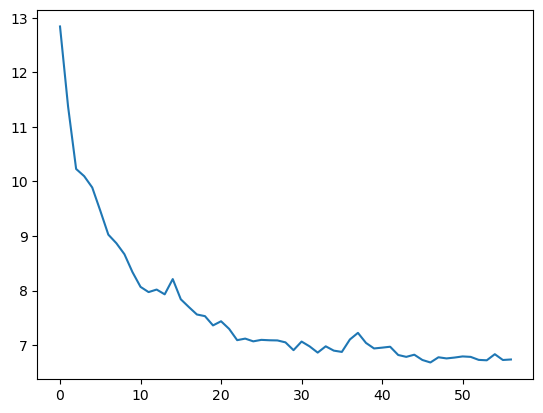

In [8]:
trainData = torch.tensor(train,device=device)
ntrain = len(train)
#loader = utils.DataLoader(trainData,batch_size=10000,shuffle=True,generator=torch.Generator(device='cuda'))
optimizer = optim.Adam(flow.parameters(),lr=1e-3)

min_loss = 1e+8
train_losses = []
patience_count = 0
print_interval=10
n_epoch=200
patience=10
bs = 10000

for i in range(n_epoch):
    perm = torch.randperm(ntrain)
    perms = torch.split(perm,bs)
    if patience_count == patience:
        break
    epoch_losses = []
    for batch_idx, p in enumerate(perms):
        x = trainData[p]
        optimizer.zero_grad()
        log_pdf,_,_ = flow(x)
        loss = -log_pdf.mean()
        loss.backward()
        optimizer.step()
        epoch_losses.append(loss.item())
        if loss.item() < min_loss:
            min_loss = loss.item()
            torch.save(flow.state_dict(),"flow.pt")
    epoch_loss = np.min(epoch_losses)
    train_losses.append(epoch_loss)
    if (i + 1) % print_interval == 0:
        print('Iteration {} Complete'.format(i + 1))
        print('Loss: ', epoch_loss)
    if epoch_loss == min_loss:
        patience_count = 0
    else:
        patience_count += 1
plt.plot(np.arange(len(train_losses)),train_losses)

In [9]:
flow.load_state_dict(torch.load('flow.pt'))

<All keys matched successfully>

In [10]:
sample_target, sample_base, log_prob_target, log_prob_base=flow.sample(allow_gradients=False, samplesize=10000)

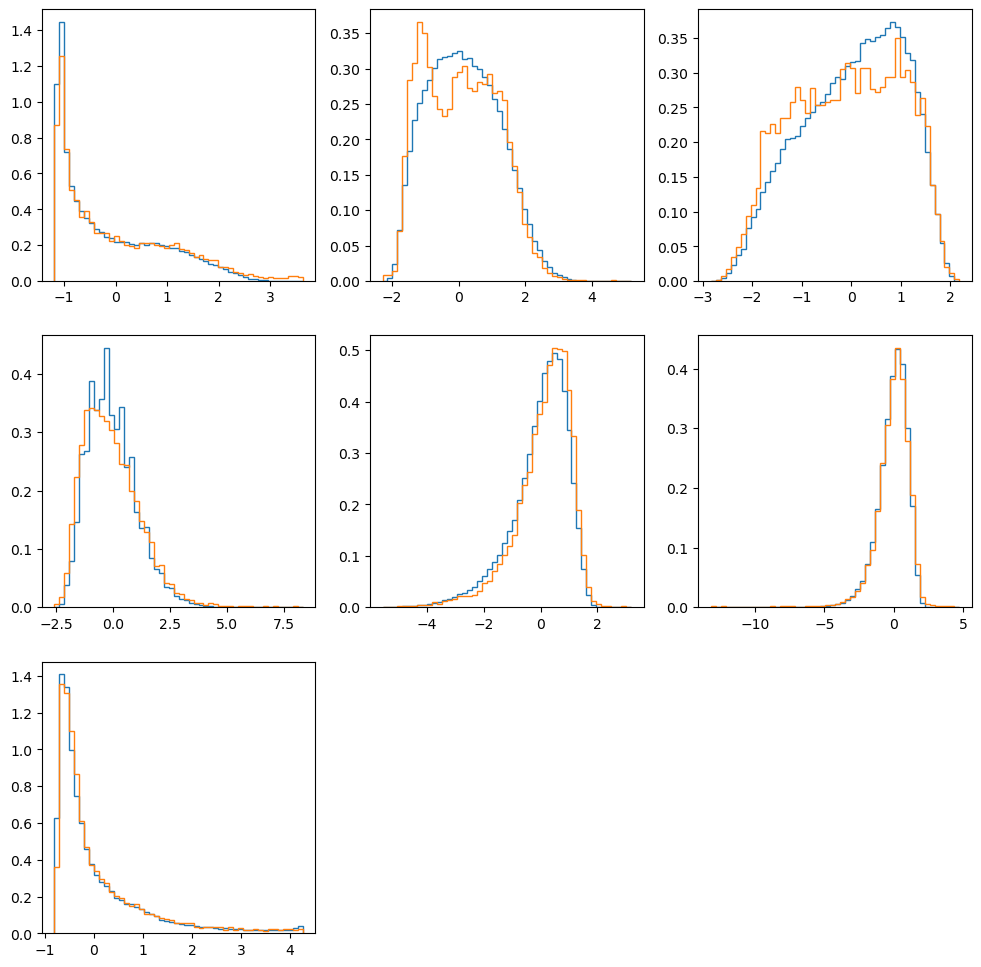

In [11]:
plt.figure(figsize=(12,12))
for i in range(train.shape[1]):
    plt.subplot(3,3,i+1)
    h2,bins,_ = plt.hist(train[:,i],bins=50,histtype='step',density=True)
    h1 = plt.hist(sample_target.detach().cpu().numpy()[:,i],bins=bins,histtype='step',density=True)
    #plt.yscale('log')

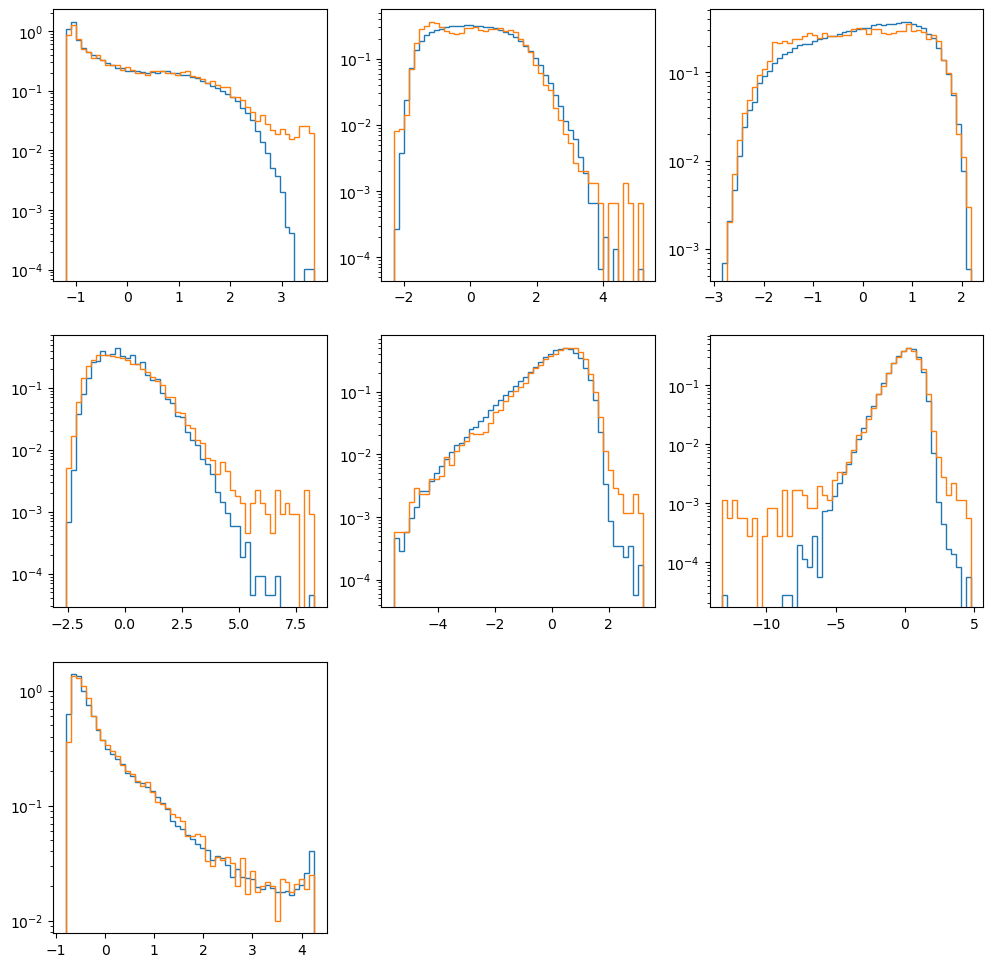

In [12]:
plt.figure(figsize=(12,12))
for i in range(train.shape[1]):
    plt.subplot(3,3,i+1)
    h2,bins,_ = plt.hist(train[:,i],bins=50,histtype='step',density=True)
    h1 = plt.hist(sample_target.detach().cpu().numpy()[:,i],bins=bins,histtype='step',density=True)
    plt.yscale('log')

In [13]:
with torch.no_grad():
    a,b,c = flow(trainData)

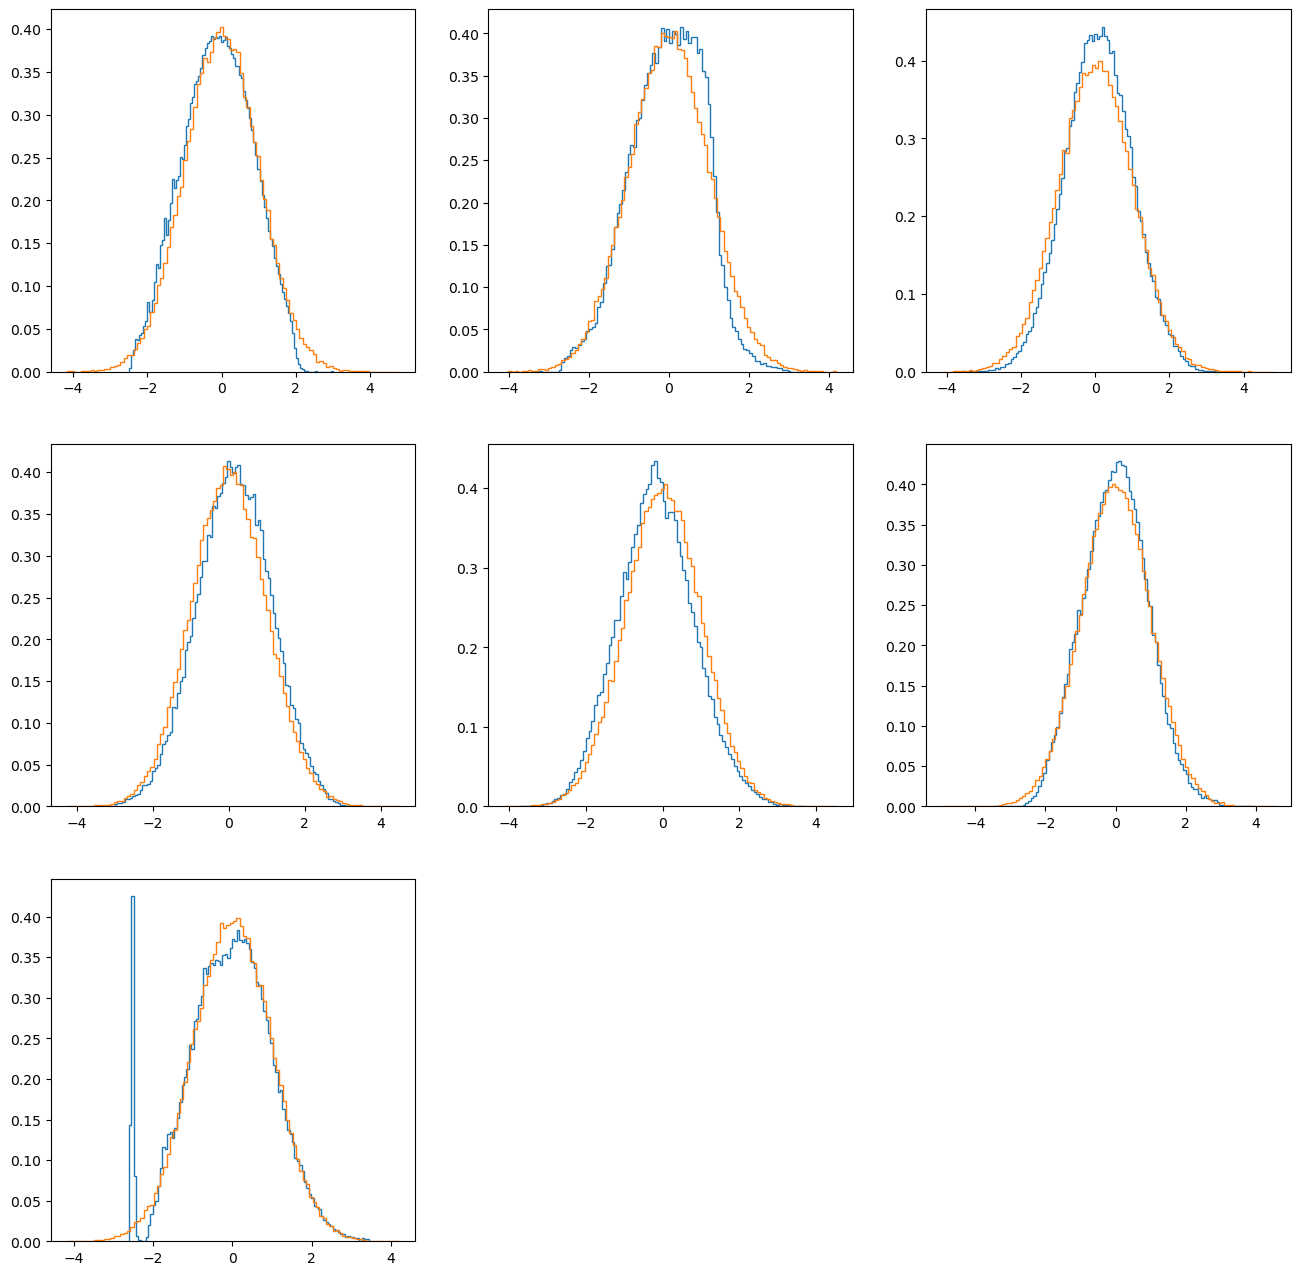

In [14]:
plt.figure(figsize=(16,16))
k = c.detach().cpu().numpy()
for i in range(len(variables)):
    plt.subplot(3,3,i+1)
    nsamp = len(k[:,i])
    h1 = plt.hist(k[:,i],bins=100,histtype='step',density=True)
    h2 = plt.hist(np.random.normal(loc=0,scale=1,size=nsamp),histtype='step',density=True,bins=100)
    #print(np.sum(h1[0]))
    #plt.yscale('log')

([<matplotlib.axis.YTick at 0x2000c2ebe410>,
 [Text(0, 0, 'jet1_rho'),
  Text(0, 1, 'jet1_tau21'),
  Text(0, 2, 'jet1_logTauS'),
  Text(0, 3, 'jet1_tau32'),
  Text(0, 4, 'jet1_tau43'),
  Text(0, 5, 'jet1_pb'),
  Text(0, 6, 'jet1_npf')])

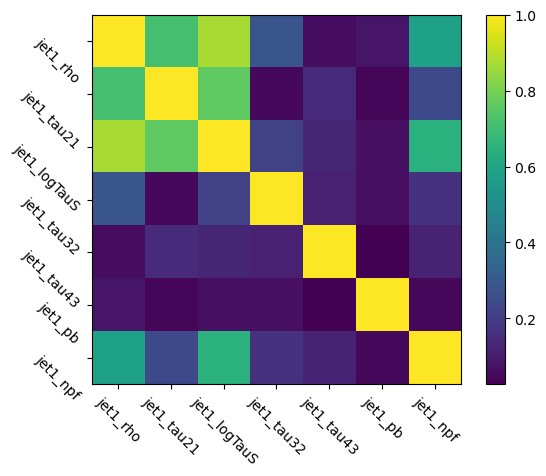

In [23]:
a = np.corrcoef(train.T)
plt.imshow(np.abs(a))
plt.colorbar()
#plt.gca().set_xticklabels(labels=['jet1_rho','jet1_tau21','jet1_tau32','jet1_tau43','jet1_logTauS','jet1_pb','jet1_npf'])
plt.xticks(ticks=np.arange(7),rotation=-45,labels=variables)
plt.yticks(ticks=np.arange(7),rotation=-45,labels=variables)

In [28]:
np.abs(a).sum(axis=1)

array([3.59371685, 2.94703399, 3.69098058, 1.89635054, 1.58896978,
       1.33370391, 2.80481845])

In [29]:
variables

['jet1_rho',
 'jet1_tau21',
 'jet1_logTauS',
 'jet1_tau32',
 'jet1_tau43',
 'jet1_pb',
 'jet1_npf']

In [30]:
variables = ['jet1_rho','jet1_logTauS','jet1_tau21','jet1_npf','jet1_tau32','jet1_tau43','jet1_pb']

In [40]:
np.max(train,axis=0)

array([3.63104248, 5.18214512, 2.18234062, 8.32469559, 3.18427467,
       4.74226141, 4.26016521])

In [3]:
sys.path.append("/home/sambt/CASE_final/CASE_QUAK_final/finalTraining")
from nflows.transforms.made import MADE

In [11]:
test = MADE(2,20,output_multiplier=3)

In [12]:
atest = torch.cat((torch.arange(0,2.1,0.1).reshape(-1,1),torch.ones(21).reshape(-1,1)),dim=1)
test(atest)

tensor([[-0.0766,  0.1331, -0.0918,  0.4444,  0.2718,  0.4874],
        [-0.0766,  0.1331, -0.0918,  0.4531,  0.2774,  0.4803],
        [-0.0766,  0.1331, -0.0918,  0.4618,  0.2829,  0.4731],
        [-0.0766,  0.1331, -0.0918,  0.4705,  0.2885,  0.4659],
        [-0.0766,  0.1331, -0.0918,  0.4792,  0.2940,  0.4588],
        [-0.0766,  0.1331, -0.0918,  0.4879,  0.2996,  0.4516],
        [-0.0766,  0.1331, -0.0918,  0.4966,  0.3051,  0.4444],
        [-0.0766,  0.1331, -0.0918,  0.5053,  0.3107,  0.4372],
        [-0.0766,  0.1331, -0.0918,  0.5140,  0.3162,  0.4300],
        [-0.0766,  0.1331, -0.0918,  0.5227,  0.3218,  0.4228],
        [-0.0766,  0.1331, -0.0918,  0.5314,  0.3273,  0.4156],
        [-0.0766,  0.1331, -0.0918,  0.5401,  0.3329,  0.4084],
        [-0.0766,  0.1331, -0.0918,  0.5488,  0.3384,  0.4012],
        [-0.0766,  0.1331, -0.0918,  0.5575,  0.3440,  0.3940],
        [-0.0766,  0.1331, -0.0918,  0.5662,  0.3495,  0.3868],
        [-0.0766,  0.1331, -0.0918,  0.5

In [9]:
atest

tensor([[0.0000, 1.0000],
        [0.1000, 1.0000],
        [0.2000, 1.0000],
        [0.3000, 1.0000],
        [0.4000, 1.0000],
        [0.5000, 1.0000],
        [0.6000, 1.0000],
        [0.7000, 1.0000],
        [0.8000, 1.0000],
        [0.9000, 1.0000],
        [1.0000, 1.0000],
        [1.1000, 1.0000],
        [1.2000, 1.0000],
        [1.3000, 1.0000],
        [1.4000, 1.0000],
        [1.5000, 1.0000],
        [1.6000, 1.0000],
        [1.7000, 1.0000],
        [1.8000, 1.0000],
        [1.9000, 1.0000],
        [2.0000, 1.0000]])